# Chapter 21 — The Electrical Resistance Strain Gage: Why It Won
### *Modern Strain Gage Technology* — Companion Notebook

**How does a change of a quarter of one percent in resistance become the workhorse of experimental mechanics?**

The strain gage is built on a single physical principle: when a conductor is deformed, its electrical resistance changes. For a metallic foil gage, this change arises from two contributions — the *geometric* change (the conductor gets longer and thinner, increasing resistance) and the *piezoresistive* effect (the resistivity of the material itself changes with strain). The ratio of fractional resistance change to strain is the **gage factor** GF, typically near 2.0 for constantan (copper-nickel) and Karma (nickel-chromium) foil alloys.

At room temperature with 5 V excitation, a 350 Ω gage at 1000 με produces a resistance change of 0.70 Ω and a quarter-bridge output of 2.5 mV — a signal so small that it demands careful amplification, low-noise wiring, and, above all, temperature compensation. The second panel below shows why: a 50 °C temperature rise in the gage alloy produces a thermal output of roughly 275 με — nearly the strain that 50 MPa of mechanical stress causes in steel.

**This notebook demonstrates:**
1. Resistance change ΔR vs. strain for a 350 Ω gage (GF = 2.00)
2. Thermal resistance change due to TCR — the temperature sensitivity that makes compensation essential

Companion notebook to Chapter 21 — The Electrical Resistance Strain Gage: Why It Won.

In [1]:
# !pip install numpy matplotlib
# ^ In Google Colab, uncomment the line above to install dependencies (preinstalled locally).

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All figures for this chapter are written here (path preserved for the book build).
OUT_DIR = Path("../src/media/ch21")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Resistance Change from Strain and Temperature

The gage factor equation ΔR/R = GF · ε is the foundation of every strain measurement. At GF = 2.00 and R_g = 350 Ω, each 1000 με of strain produces a 0.724 Ω resistance change — less than 0.21% of the total resistance. Detecting this reliably against a background of thermal drift, lead-wire resistance variation, and EMI is the engineering challenge that drove the development of the Wheatstone bridge, precision amplifiers, and shielded cabling.

The right panel shows the thermal side of the same equation: the TCR (temperature coefficient of resistance) of the gage alloy produces a resistance change of similar magnitude for temperature variations as small as 25–50°C. The comparison between the two panels is instructive — at typical test temperatures, thermal effects can easily exceed the mechanical signal by a factor of 2–5× if not compensated. This is why STC gage selection and dummy-gage or half-bridge wiring are not optional refinements but essential practice.

In [2]:
# --- Model parameters (edit these to explore your own gage) ---
GF  = 2.00     # gage factor (dimensionless), typical metallic foil
Rg  = 350.0    # nominal gage resistance (Ω)
Vex = 5.0      # bridge excitation voltage (V)
TCR = 11.0     # temperature coefficient of resistance of the grid alloy (ppm/°C)

# --- Plot ranges ---
EPS_MAX  = 3000e-6   # maximum mechanical strain to plot (3000 με)
N_STRAIN = 300       # samples along the strain axis
DT_MAX   = 100.0     # maximum temperature rise to plot (°C)
N_TEMP   = 100       # samples along the temperature axis

# --- Reference operating point used in the printed summary ---
EPS_REF = 1000e-6    # reference strain (1000 με)
DT_REF  = 50.0       # reference temperature rise (°C)


def resistance_change_from_strain(gage_factor, gage_resistance, strain):
    """Absolute resistance change ΔR (Ω) from mechanical strain.

    Rearranges the gage-factor relation ΔR/R = GF·ε into ΔR = GF·R·ε.
    """
    return gage_factor * gage_resistance * strain


def quarter_bridge_output(excitation, gage_factor, strain):
    """Open-circuit quarter-bridge output voltage (V): Vout = Vex·GF·ε / 4.

    Valid for a single active arm; the factor of 4 is the bridge sensitivity.
    """
    return excitation * gage_factor * strain / 4.0


def resistance_change_from_temperature(gage_resistance, tcr_ppm_per_c, delta_t):
    """Resistance change ΔR (Ω) from a temperature change: ΔR = R·TCR·ΔT.

    ``tcr_ppm_per_c`` is expressed in ppm/°C and scaled by 1e-6 internally.
    """
    return gage_resistance * tcr_ppm_per_c * 1e-6 * delta_t


def thermal_output_from_temperature(tcr_ppm_per_c, delta_t, gage_factor):
    """Thermal output in με: the strain reading a bare gage's TCR mimics.

    The thermal resistance change TCR·ΔT looks exactly like a mechanical
    strain of ε_T/O = (ΔR/R) / GF = TCR·ΔT / GF (result already in με).
    """
    return tcr_ppm_per_c * delta_t / gage_factor

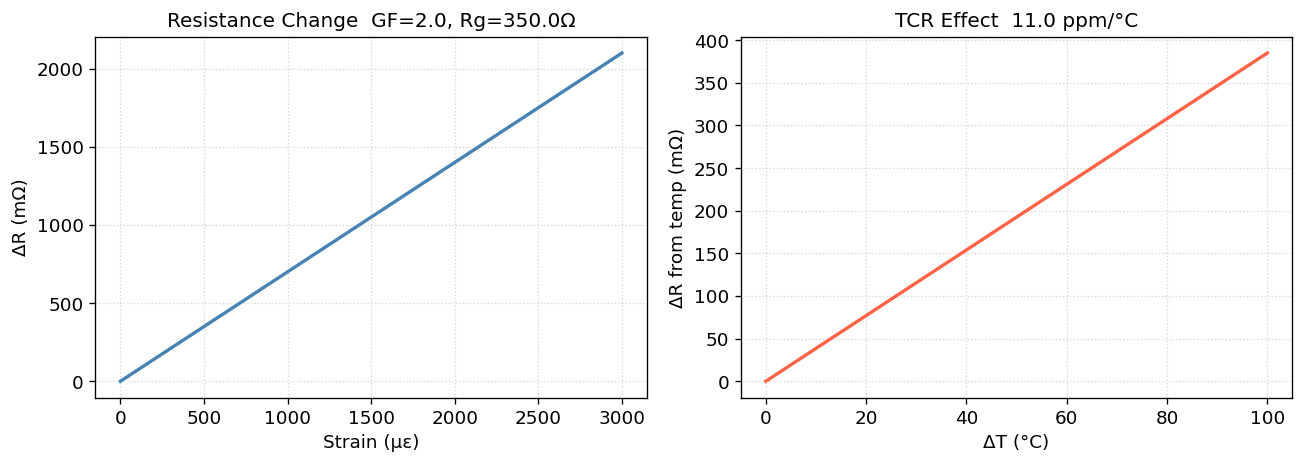

At ε = 1000 με: ΔR = 700.00 mΩ, quarter-bridge Vout ≈ 2.500 mV
50°C temperature rise → thermal output ≈ 275.0 με


In [3]:
# Sweep strain and temperature across the plotted ranges
eps = np.linspace(0.0, EPS_MAX, N_STRAIN)
dR = resistance_change_from_strain(GF, Rg, eps)          # Ω

dT = np.linspace(0.0, DT_MAX, N_TEMP)
dRg_T = resistance_change_from_temperature(Rg, TCR, dT)  # Ω

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(eps*1e6, dR*1000, 'steelblue', lw=2)
axes[0].set_xlabel('Strain (με)'); axes[0].set_ylabel('ΔR (mΩ)')
axes[0].set_title(f'Resistance Change  GF={GF}, Rg={Rg}Ω'); axes[0].grid(True,linestyle=':',alpha=0.5)
axes[1].plot(dT, dRg_T*1000, 'tomato', lw=2)
axes[1].set_xlabel('ΔT (°C)'); axes[1].set_ylabel('ΔR from temp (mΩ)')
axes[1].set_title(f'TCR Effect  {TCR} ppm/°C'); axes[1].grid(True,linestyle=':',alpha=0.5)
plt.tight_layout(); plt.savefig(OUT_DIR / 'fig21_nb1_resistance_change_strain.png', bbox_inches='tight', dpi=300)
plt.show()

# Numeric summary at the reference operating point
dR_ref = resistance_change_from_strain(GF, Rg, EPS_REF)           # Ω
vout_ref = quarter_bridge_output(Vex, GF, EPS_REF)               # V
eps_to_ref = thermal_output_from_temperature(TCR, DT_REF, GF)     # με
print(f"At ε = {EPS_REF*1e6:.0f} με: ΔR = {dR_ref*1000:.2f} mΩ, "
      f"quarter-bridge Vout ≈ {vout_ref*1000:.3f} mV")
print(f"{DT_REF:.0f}°C temperature rise → thermal output ≈ {eps_to_ref:.1f} με")

---
## Where to take this next

- **Overlay a second alloy.** Karma (K-alloy) has a higher intrinsic TCR than constantan but is prized for its flatter *self-temperature-compensation* behavior over a wide range. Re-plot the right panel for a second `TCR` value and compare the raw thermal outputs side by side.
- **Use a real thermal-output curve.** Production STC gages are matched to a substrate (for example, steel, STC 06) and characterized by a *thermal-output* polynomial, not a single TCR. Swap `resistance_change_from_temperature` for a manufacturer's fourth-order thermal-output curve and watch how compensation flattens — but never fully cancels — the thermal signal (the correction developed in Chapter 19).
- **Sweep the bridge configuration.** Generalize `quarter_bridge_output` into quarter-, half-, and full-bridge cases and plot output voltage versus strain for each, showing how additional active arms multiply sensitivity and reject temperature — the bridge circuits taken up in Chapters 26 and 27.